# 01 — Language Detection
EDA, feature inspection, model evaluation deep-dive.


In [1]:
import sys, pickle
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SPLITS    = ROOT / 'data' / 'splits'
MODEL_DIR = ROOT / 'models' / 'language_detection'

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Ready')

Ready


## 1. Exploratory Data Analysis

In [3]:
train = pd.read_csv('../data/splits/train/language_train.csv')
val   = pd.read_csv('../data/splits/val/language_val.csv')
test  = pd.read_csv('../data/splits/test/language_test.csv')

print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')
train.head(4)

train=60,132  val=7,516  test=7,517


,labels,text
0,sw,"Katika barabara kubwa ya bustani hiyo, hiyo il..."
1,en,"they send me a scale in envelope ,unbelievable..."
2,th,ชื่อ ที่ ถูกต้อง เพิ่มเติม สำหรับ อาคาร ของ อา...
3,vi,sao hỏa ! anh ta đã bán được .


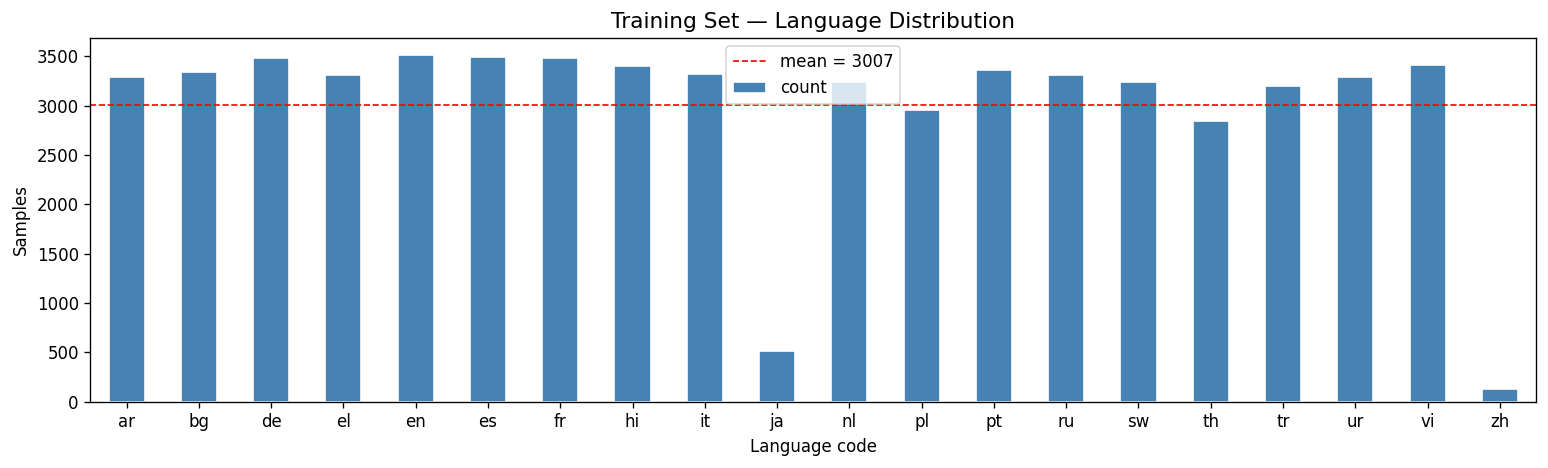

Class imbalance (max/min ratio): 27.86x


In [5]:
# ── Language distribution ────────────────────────────────────────────────────
counts = train['labels'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(13, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Training Set — Language Distribution', fontsize=13)
ax.set_xlabel('Language code')
ax.set_ylabel('Samples')
ax.axhline(counts.mean(), color='red', linestyle='--', linewidth=1,
           label=f'mean = {counts.mean():.0f}')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Class imbalance (max/min ratio):', f"{counts.max()/counts.min():.2f}x")

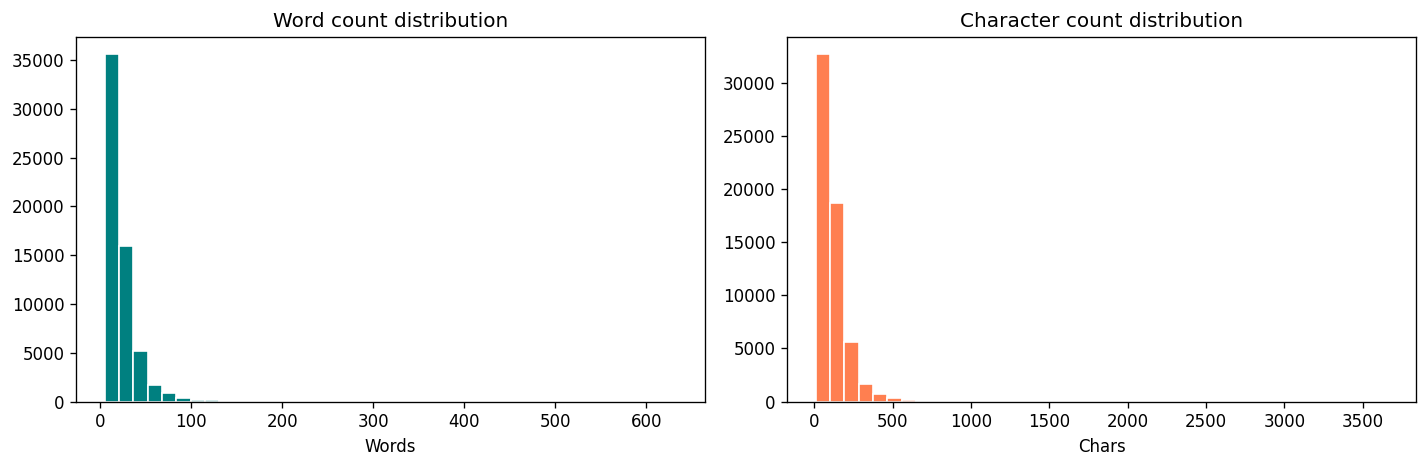

,word_count,char_count
count,60132.0,60132.0
mean,22.1,120.4
std,19.3,105.9
min,5.0,11.0
25%,10.0,55.0
50%,17.0,94.0
75%,28.0,152.0
max,633.0,3657.0


In [6]:
# ── Text length distribution ─────────────────────────────────────────────────
train['word_count'] = train['text'].str.split().apply(len)
train['char_count'] = train['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train['word_count'], bins=40, color='teal', edgecolor='white')
axes[0].set_title('Word count distribution'); axes[0].set_xlabel('Words')
axes[1].hist(train['char_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Character count distribution'); axes[1].set_xlabel('Chars')
plt.tight_layout()
plt.show()
train[['word_count','char_count']].describe().round(1)

In [8]:
# ── Sample texts from 5 languages ────────────────────────────────────────────
LANG_NAMES = {'en':'English','fr':'French','ar':'Arabic','ja':'Japanese','ru':'Russian'}
for lang, name in LANG_NAMES.items():
    sample = train[train['labels']==lang]['text'].iloc[0]
    print(f"  [{lang}] {name}:")
    print(f"    {sample[:120]}")
    print()

  [en] English:
    they send me a scale in envelope ,unbelievable! and of course after two weeks the scale it doesn't anymore you are so st

  [fr] French:
    Produit qui ne fonctionne pas...

  [ar] Arabic:
    و الموجزات الوقت للجنة لانقاذ العالم : وزير الخزانة روبرت روبن , نائب الامين لورنس سامرز , ورئيس الاحتياطي الفيدرالي الا

  [ja] Japanese:
    お金に困っている潜入捜査官と友人の警官が、報奨金目当てにチームプレイを無視して犯人検挙をしたが、報奨金は貰えなかった。 そして現金強奪を企てる犯罪組織に入る。 それに誘ったが、頑なに正義を貫く友人警官は組織に捕まる。 友人を気にしながらも、

  [ru] Russian:
    Из немногих останков в города , самое замечательное здание - в София .



## 2. Feature Inspection

In [9]:
# Load saved vectorizer and model
with open(MODEL_DIR / 'vectorizer.pkl', 'rb') as f:
    vec = pickle.load(f)
with open(MODEL_DIR / 'model.pkl', 'rb') as f:
    clf = pickle.load(f)

print(f'Vocabulary size : {len(vec.vocabulary_):,}')
print(f'Classes         : {list(clf.classes_)}')

Vocabulary size : 50,000
Classes         : ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


d:\Desktop\ITI Notes\NLP\Mental Health Chatbot\mental_health_chatbot\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Desktop\ITI Notes\NLP\Mental Health Chatbot\mental_health_chatbot\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\Desktop\ITI Notes\NLP\Mental Health Chatbot\mental_health_chatbot\venv\Lib\site-packages\sklearn\base.py

C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12394 (\N{HIRAGANA LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_4348\860069570.py:17: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.

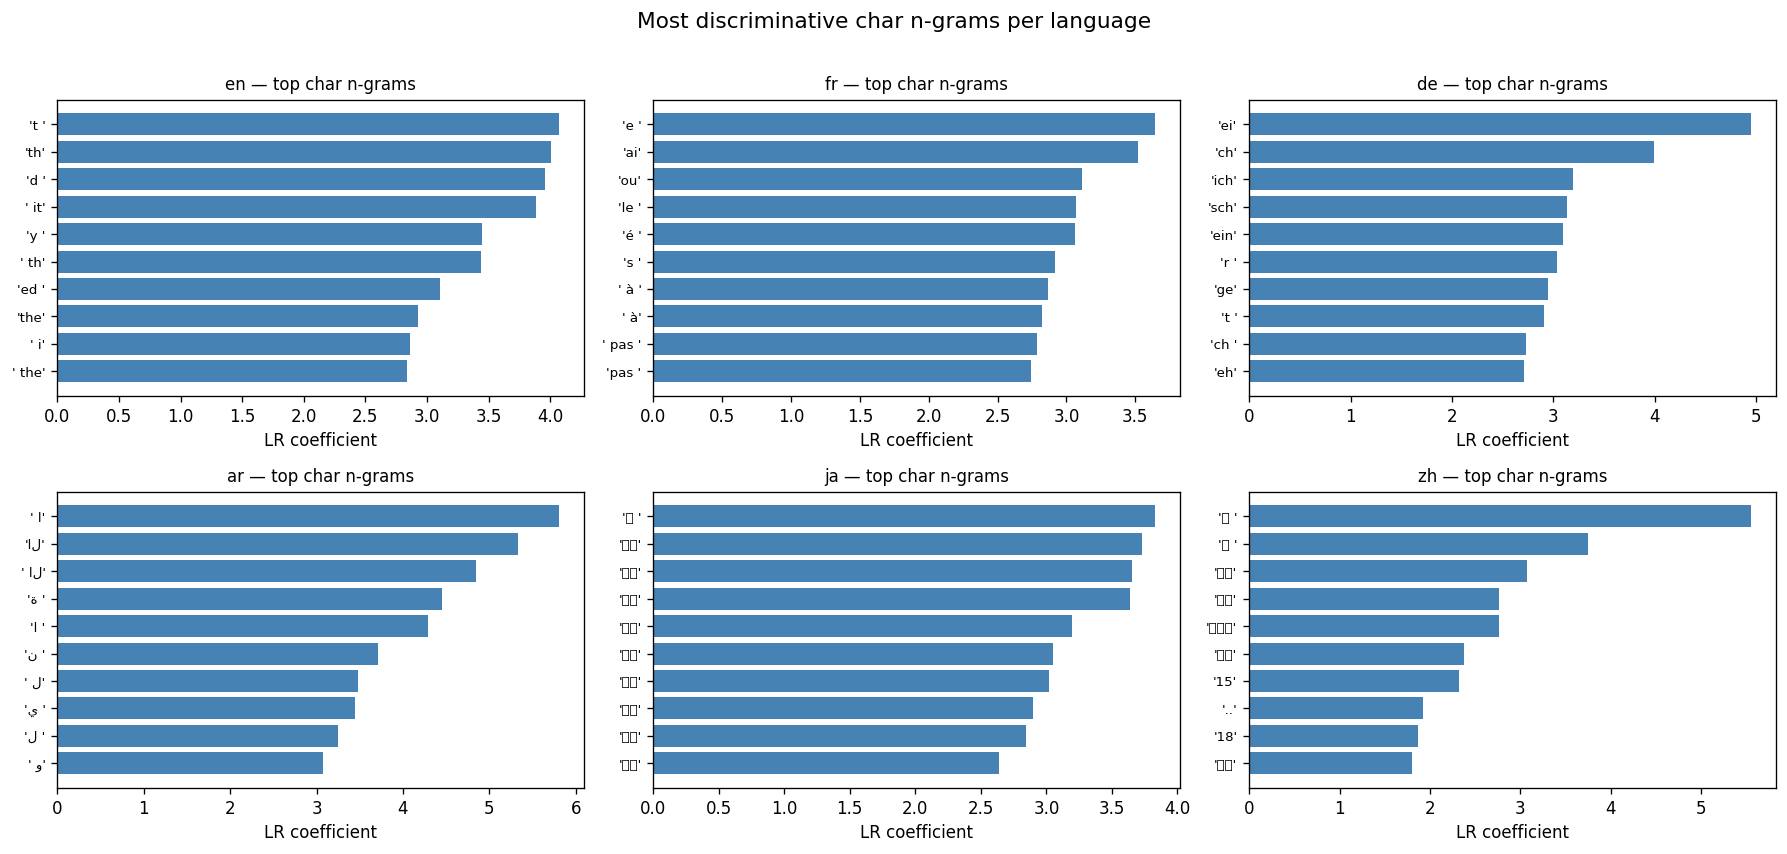

In [10]:
# Top 10 char n-grams per language
feature_names = np.array(vec.get_feature_names_out())
SHOW = ['en', 'fr', 'de', 'ar', 'ja', 'zh']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, lang in zip(axes.flat, SHOW):
    idx = list(clf.classes_).index(lang)
    top_idx = np.argsort(clf.coef_[idx])[-10:][::-1]
    top_feat = feature_names[top_idx]
    top_vals = clf.coef_[idx][top_idx]
    ax.barh(range(10), top_vals[::-1], color='steelblue')
    ax.set_yticks(range(10))
    ax.set_yticklabels([repr(f) for f in top_feat[::-1]], fontsize=8)
    ax.set_title(f'{lang} — top char n-grams', fontsize=10)
    ax.set_xlabel('LR coefficient')
plt.suptitle('Most discriminative char n-grams per language', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Evaluation

In [12]:
X_test = vec.transform(test['text'])
y_pred = clf.predict(X_test)
y_test = test['labels']

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}  ({acc*100:.2f}%)')
print()
print(classification_report(y_test, y_pred))

Test accuracy: 0.9968  (99.68%)

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       411
          bg       1.00      0.99      0.99       418
          de       1.00      1.00      1.00       436
          el       1.00      1.00      1.00       414
          en       0.98      1.00      0.99       439
          es       1.00      1.00      1.00       438
          fr       1.00      1.00      1.00       435
          hi       1.00      0.99      1.00       425
          it       1.00      1.00      1.00       415
          ja       1.00      0.98      0.99        64
          nl       1.00      1.00      1.00       404
          pl       1.00      0.99      1.00       370
          pt       0.99      0.99      0.99       421
          ru       0.99      1.00      0.99       413
          sw       1.00      0.99      1.00       405
          th       1.00      1.00      1.00       355
          tr       1.00      1.00      1.00     

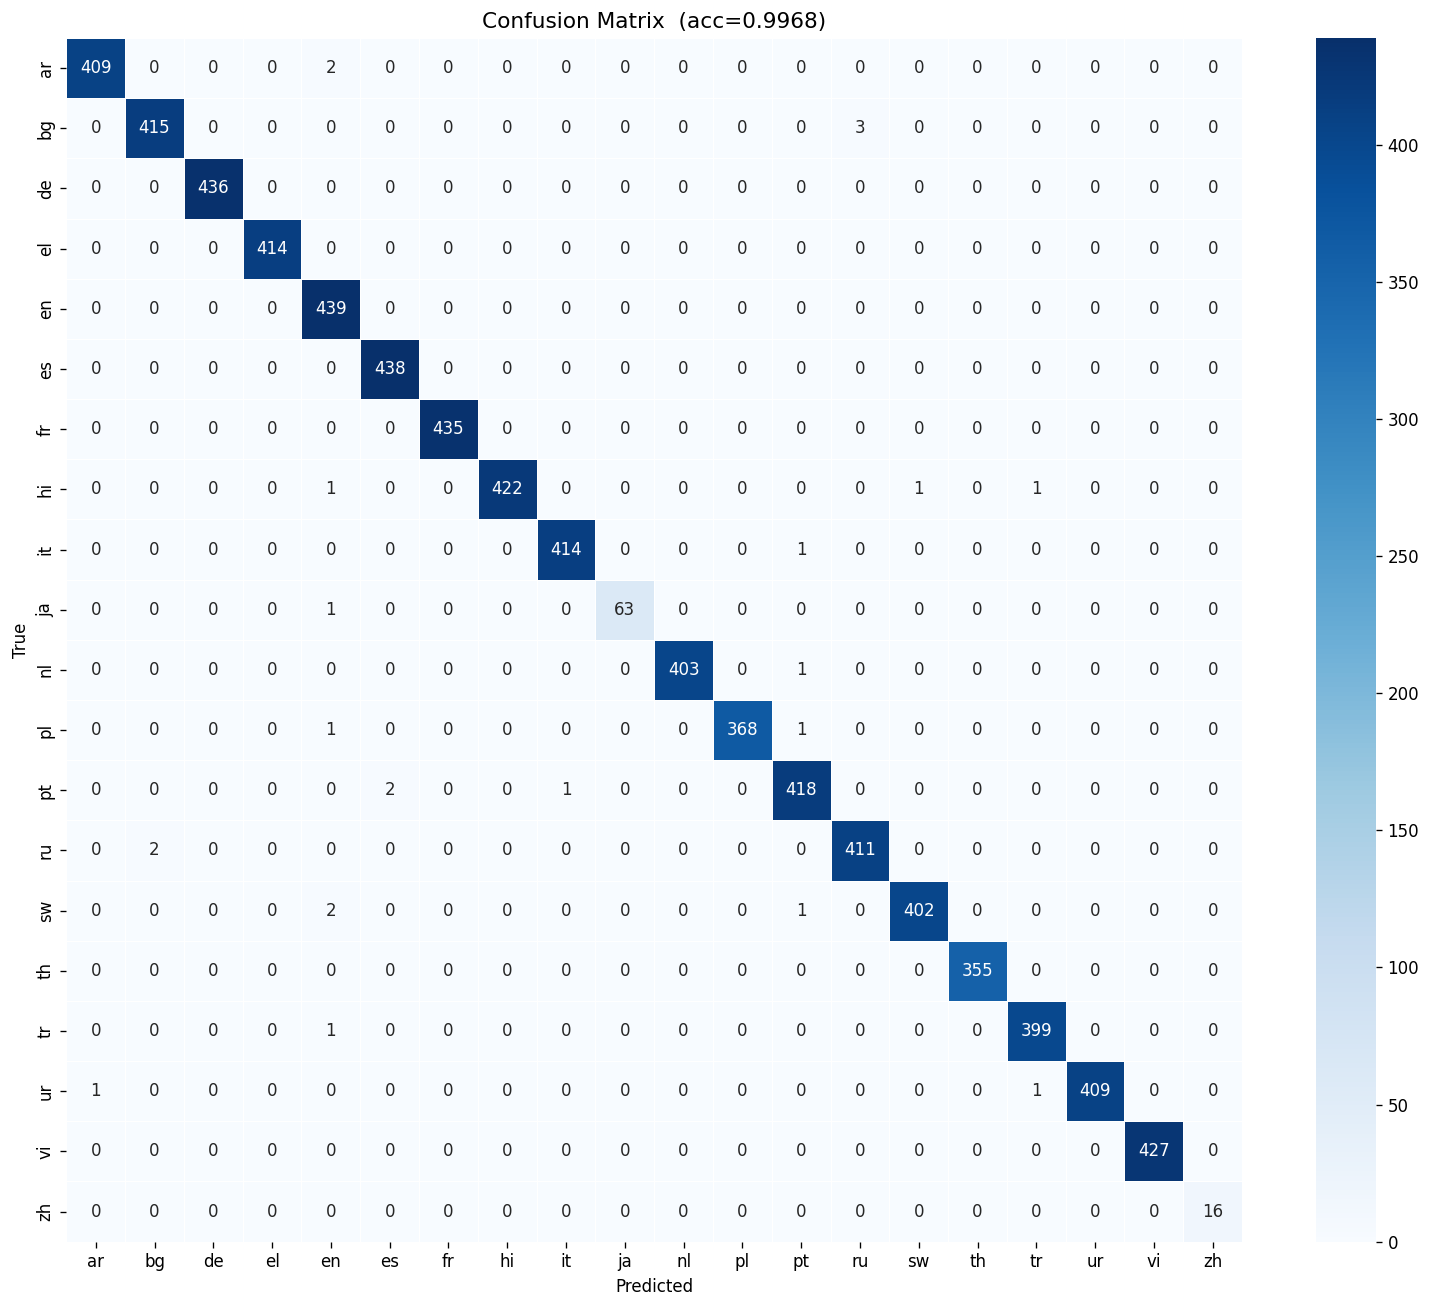

In [13]:
# Confusion matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.3, ax=ax)
ax.set_title(f'Confusion Matrix  (acc={acc:.4f})', fontsize=13)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

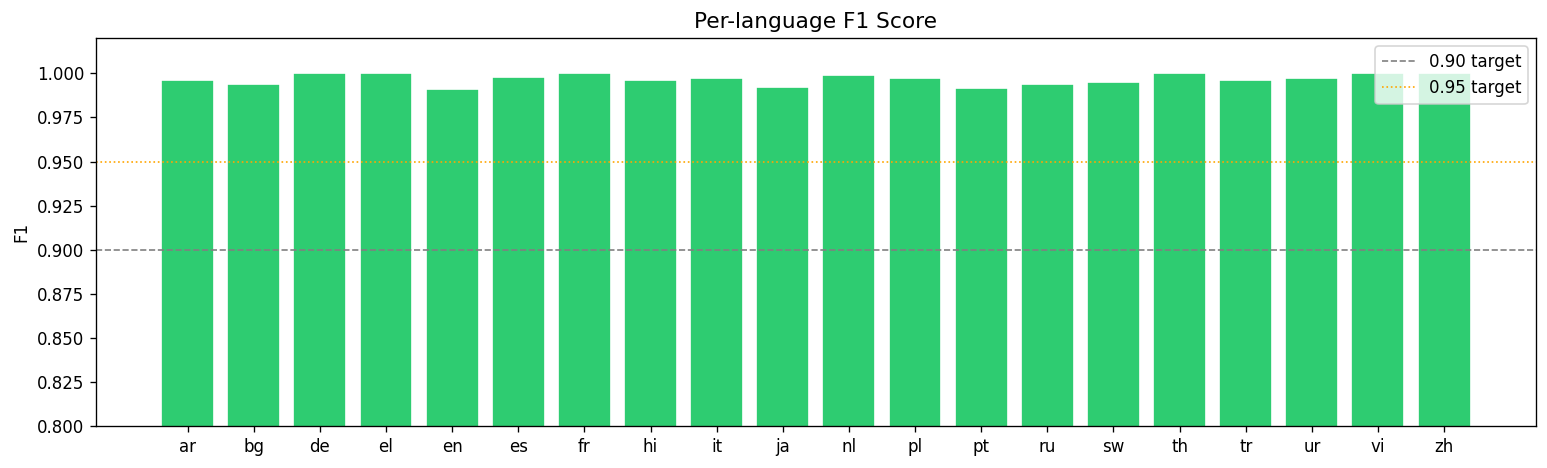

In [14]:
# Per-language F1 bar chart
report = classification_report(y_test, y_pred, output_dict=True)
langs = [l for l in labels if l in report]
f1s   = [report[l]['f1-score'] for l in langs]

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#e74c3c' if f < 0.90 else '#2ecc71' for f in f1s]
ax.bar(langs, f1s, color=colors, edgecolor='white')
ax.axhline(0.90, color='grey', linestyle='--', linewidth=1, label='0.90 target')
ax.axhline(0.95, color='orange', linestyle=':', linewidth=1, label='0.95 target')
ax.set_ylim(0.80, 1.02)
ax.set_title('Per-language F1 Score', fontsize=13)
ax.set_ylabel('F1')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Wrapper Class Demo

In [29]:
from src.language_detector import LanguageDetector

detector = LanguageDetector()

examples = [
    "I feel really anxious and can't sleep at night.",
    "Je me sens triste et incompris depuis quelques semaines.",
    "Tengo mucho miedo y no sé qué hacer con mi vida.",
    "私は最近とても気分が落ち込んでいます。",
    "أشعر بالقلق الشديد ولا أستطيع التركيز.",
    "Ich habe Angst und fühle mich sehr allein.",
    "Hello How are you?"
]

print(f'{'Text':<50}  {'Lang':<6}  {'Conf':>6}')
print('-' * 65)
for text in examples:
    r = detector.detect(text)
    print(f"{text[:48]:<50}  {r['language']:<6}  {r['confidence']:>6.3f}")

Text                                                Lang      Conf
-----------------------------------------------------------------
I feel really anxious and can't sleep at night.     en       0.916
Je me sens triste et incompris depuis quelques s    fr       0.706
Tengo mucho miedo y no sé qué hacer con mi vida.    es       0.971
私は最近とても気分が落ち込んでいます。                                 ja       0.000
أشعر بالقلق الشديد ولا أستطيع التركيز.              ar       0.995
Ich habe Angst und fühle mich sehr allein.          de       0.998
Hello How are you?                                  it       0.192
